# Binomial Distribution Simulation

This notebook simulates the binomial distribution across different combinations of:
- **p** = probability of success on each trial
- **n** = number of trials per experiment

We repeat each experiment 10,000 times to get a smooth, reliable distribution.

We also overlay a **normal approximation** (KDE line) when both `n*p > 5` and `n*(1-p) > 5` -- the standard rule-of-thumb for when the binomial is well-approximated by a normal distribution.

## 1. Import Libraries

In [1]:
import numpy as np              # Efficient random number generation
import pandas as pd             # Organise results into a tidy DataFrame
import seaborn as sns           # FacetGrid visualisations
import matplotlib.pyplot as plt  # Plot customisation

sns.set_style("ticks")

## 2. Simulation Parameters

Change these to explore different scenarios.

In [2]:
# Probability of success on a single trial
probabilities = [0.01, 0.1, 0.5, 0.7]

# Number of trials in each experiment
num_trials = [1, 5, 10, 100, 1000]

# How many times we repeat each experiment
# More simulations = smoother histogram, but slower to run
num_simulations = 10_000

print(f"Total experiments to simulate: {len(probabilities) * len(num_trials)}")
print(f"Total rows in results DataFrame: {len(probabilities) * len(num_trials) * num_simulations:,}")

Total experiments to simulate: 20
Total rows in results DataFrame: 200,000


## 3. Run Simulations

For each combination of (p, n) we use `np.random.binomial` to simulate `num_simulations` experiments at once.

Each value in the result is the number of successes out of `n` trials, with each trial having probability `p` of success.

In [3]:
all_results = []

print("Running simulations...")

for p in probabilities:
    for n in num_trials:
        # Simulate num_simulations experiments in one vectorised call
        # Returns an array of length num_simulations, each value = successes in n trials
        success_counts = np.random.binomial(n, p, size=num_simulations)

        # Store results in a tidy long-format DataFrame with labels for each combo
        all_results.append(pd.DataFrame({
            'num_successes':   success_counts,
            'probability_p':   p,
            'num_trials_n':    n
        }))

# Stack all individual DataFrames into one long table
df_results = pd.concat(all_results, ignore_index=True)

print(f"Done. DataFrame shape: {df_results.shape}")
df_results.head(10)

Running simulations...
Done. DataFrame shape: (200000, 3)


,num_successes,probability_p,num_trials_n
0,0,0.01,1
1,0,0.01,1
2,0,0.01,1
3,0,0.01,1
4,0,0.01,1
5,0,0.01,1
6,0,0.01,1
7,0,0.01,1
8,0,0.01,1
9,0,0.01,1


## 4. Visualise

### Grid layout
Each **row** = one value of p | Each **column** = one value of n

### Normal approximation overlay
A black KDE line is added when **both** conditions hold:
- `n * p > 5`
- `n * (1 - p) > 5`

These are the standard conditions under which the binomial distribution is well-approximated by a normal. When either condition fails (e.g. very small p or very small n), the distribution is skewed and the normal approximation is not appropriate.

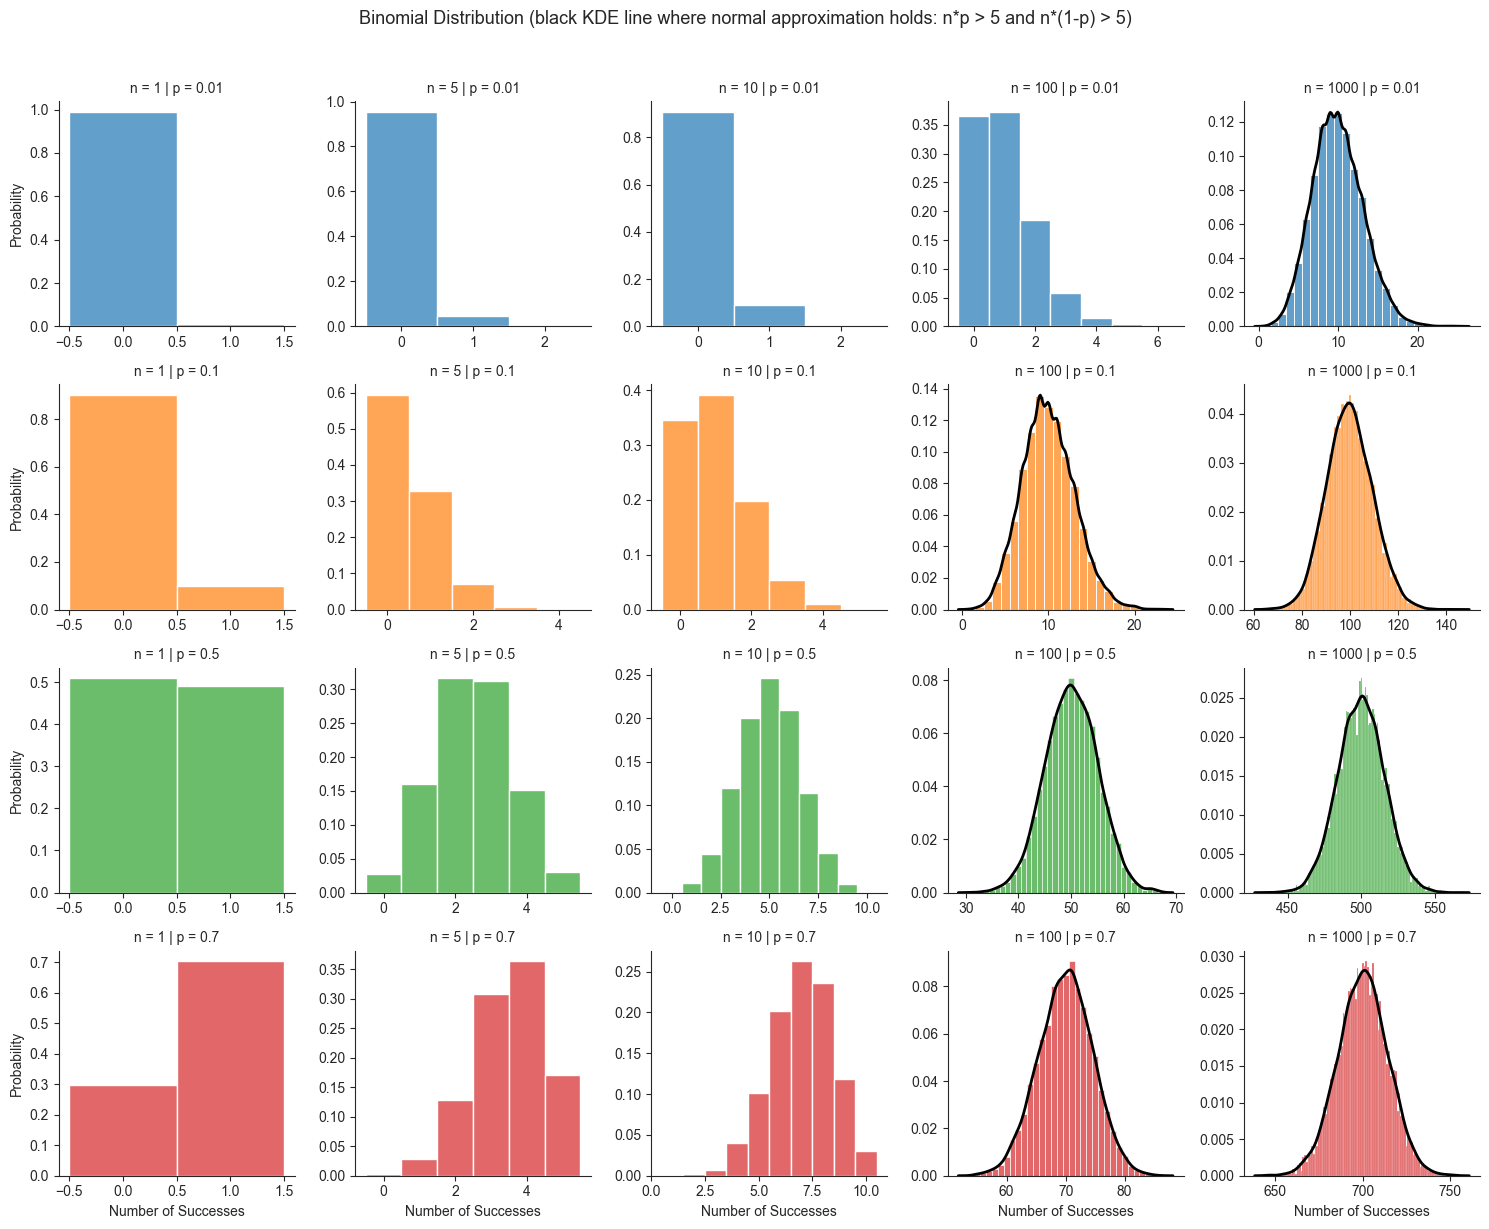

In [4]:
# --- Build the FacetGrid skeleton ---
# row = p values, col = n values; sharex/sharey=False because scales differ across facets
g = sns.FacetGrid(
    data=df_results,
    row='probability_p',
    col='num_trials_n',
    hue='probability_p',
    sharex=False,
    sharey=False
)

# --- Draw histogram on every facet ---
# stat='probability' normalises the y-axis so bars sum to 1 (a PMF)
# discrete=True treats each integer as its own bar with no gaps
g.map_dataframe(
    sns.histplot,
    x='num_successes',
    stat='probability',
    discrete=True,
    alpha=0.7
)

# --- Conditionally add a KDE density line ---
# Iterate over every (p, n) facet and check the normal approximation conditions
for (p, n), ax in g.axes_dict.items():
    if n * p > 5 and n * (1 - p) > 5:
        # Filter the full DataFrame to just the data for this facet
        facet_data = df_results[
            (df_results['probability_p'] == p) &
            (df_results['num_trials_n'] == n)
        ]
        # Draw KDE on this specific axis -- ax=ax is what pins it to the right panel
        sns.kdeplot(
            data=facet_data,
            x='num_successes',
            color='black',
            linewidth=2,
            ax=ax
        )

# --- Labels and titles ---
g.fig.suptitle(
    'Binomial Distribution (black KDE line where normal approximation holds: n*p > 5 and n*(1-p) > 5)',
    fontsize=13, y=1.02
)
g.set_titles("n = {col_name} | p = {row_name}")
g.set_axis_labels("Number of Successes", "Probability")

plt.tight_layout()
plt.show()

## 5. Key Takeaways

| Condition | What you see |
|---|---|
| Small p, small n (e.g. p=0.01, n=1) | Almost all mass at 0, very right-skewed |
| Large n, p=0.5 | Symmetric bell curve, KDE line fits well |
| Large n, small p (e.g. p=0.01, n=1000) | np=10 > 5, so normal approx works |
| Small n regardless of p | Discrete spikes, KDE line absent or misleading |

**Central Limit Theorem in action**: as n increases, the binomial converges to a normal distribution -- but only when n is large enough relative to p.